# LOADING LIBRARIES

In [1]:
import torch
import numpy as np
import pandas as pd

# LOADING DATASET

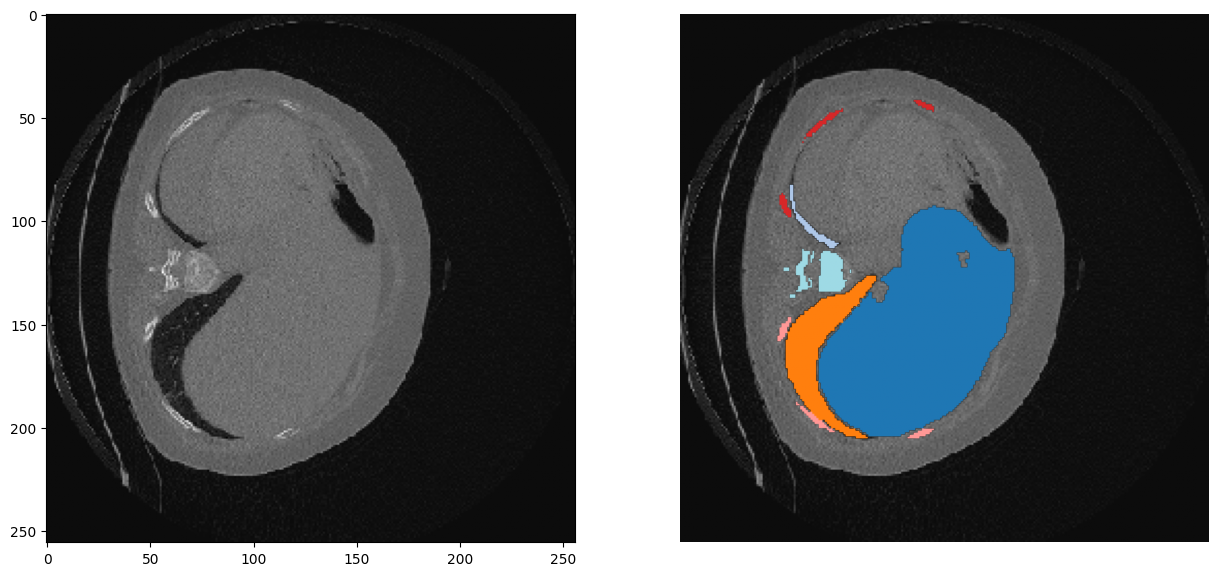

In [2]:
from sklearn.model_selection import train_test_split

from src.plotting import plt_sample
from src.dataset import load_preprocessed_dataset


x_train, y_train, x_test = load_preprocessed_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=1,
)
x_test = x_test.cpu()
SAMPLE_IDX = 0
plt_sample(x_train[SAMPLE_IDX].squeeze(), y_train[SAMPLE_IDX])

# Swin-UNET

torch.Size([683, 1, 256, 256]) torch.Size([683, 256, 256])
torch.Size([8, 1, 256, 256]) torch.Size([8, 256, 256])
y_pred torch.Size([8, 55, 256, 256])
torch.Size([1, 1, 256, 256])


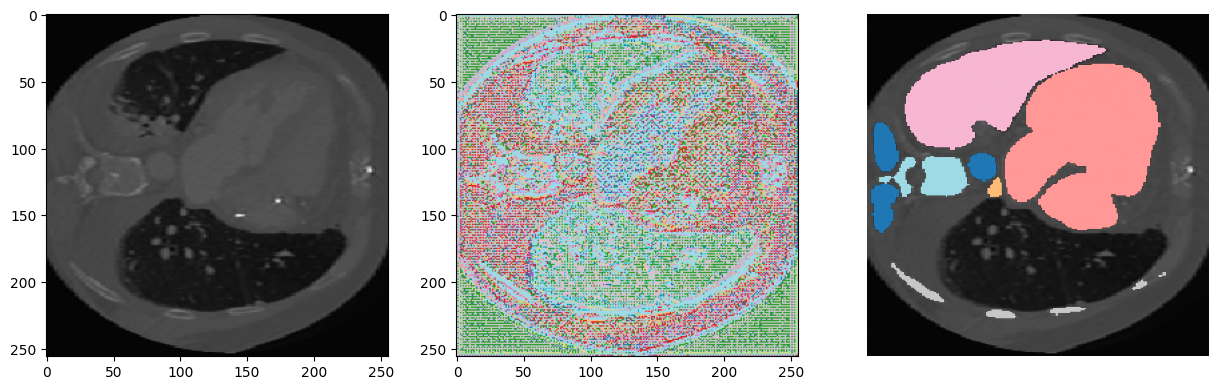

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch : 0 	 Training Loss : 2.188 	 Test Loss : 1.907 	 Score: 0.009
torch.Size([1, 1, 256, 256])


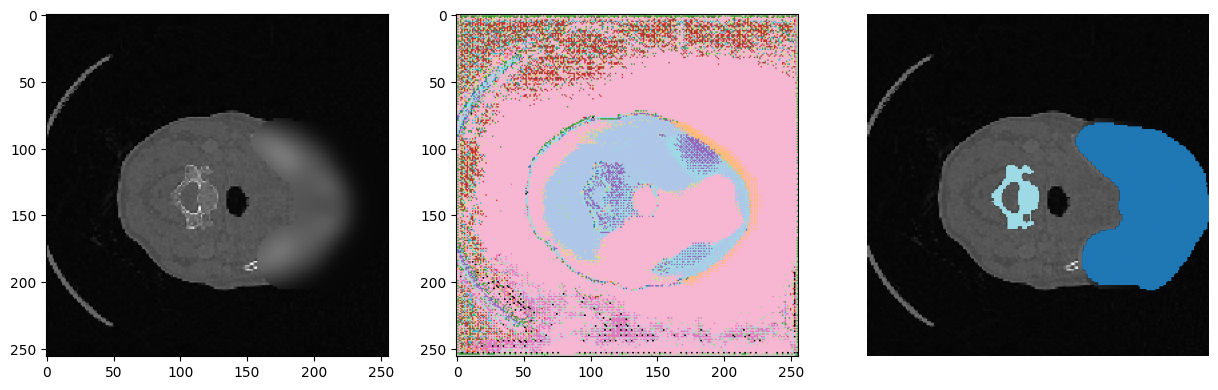

torch.Size([1, 1, 256, 256])


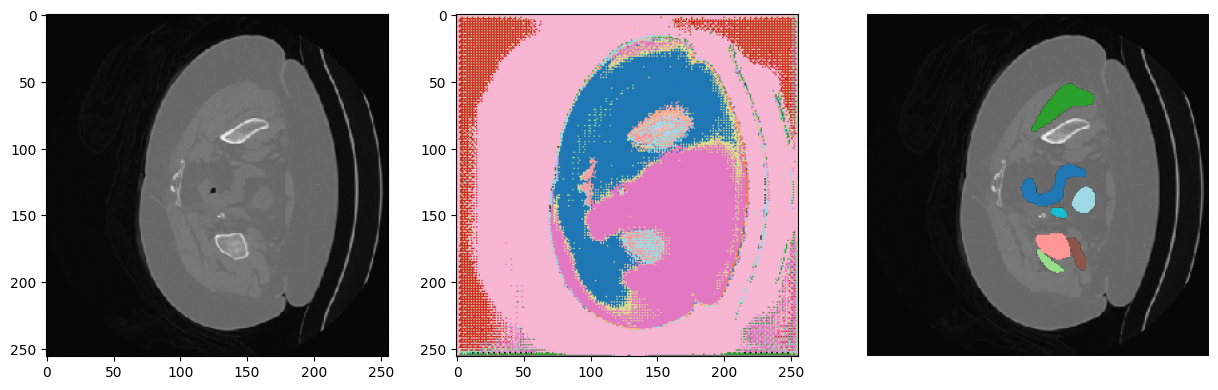

torch.Size([1, 1, 256, 256])


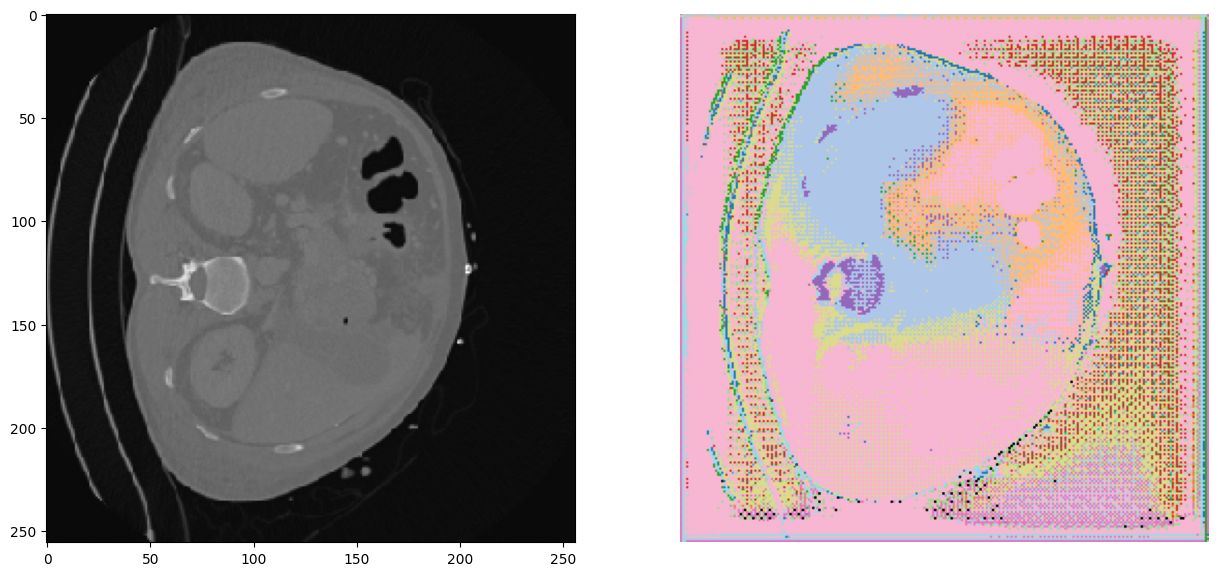

In [3]:
from torch import nn, Tensor
from monai.networks.nets import SwinUNETR

from src.training import train_unet
from src.dataset import get_data_loaders
from src.metrics import get_class_weights, SegmentationLoss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 55
def mk_model() -> nn.Module:
    return SwinUNETR(
        in_channels=1,
        out_channels=NUM_CLASSES,
        feature_size=48,
        spatial_dims=2,
        use_v2=True,
    ).to(device)

model = mk_model()

train_loader, valid_loader = get_data_loaders(
    x_train,
    y_train,
    x_valid,
    y_valid,
    batch_size=8,
)
N_EPOCHS = 1
class_weights = get_class_weights().to(device)
cirterion = SegmentationLoss(class_weights)
train_unet(
    model,
    device,
    train_loader,
    valid_loader,
    N_EPOCHS,
    NUM_CLASSES,
    cirterion,
    save_checkpoint=True,
    plt_preds=True,
    x_test=x_test,
)
del train_loader
del valid_loader
del model

torch.Size([1, 1, 256, 256])


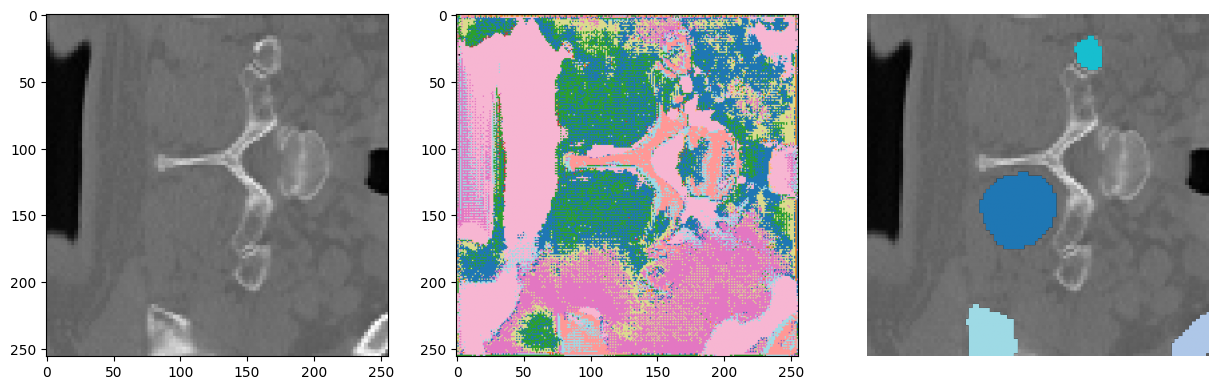

torch.Size([1, 1, 256, 256])


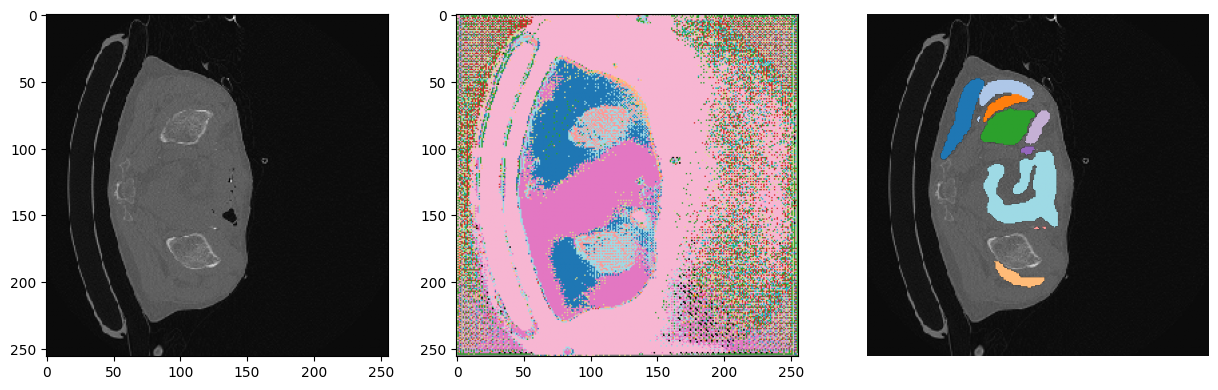

torch.Size([1, 1, 256, 256])


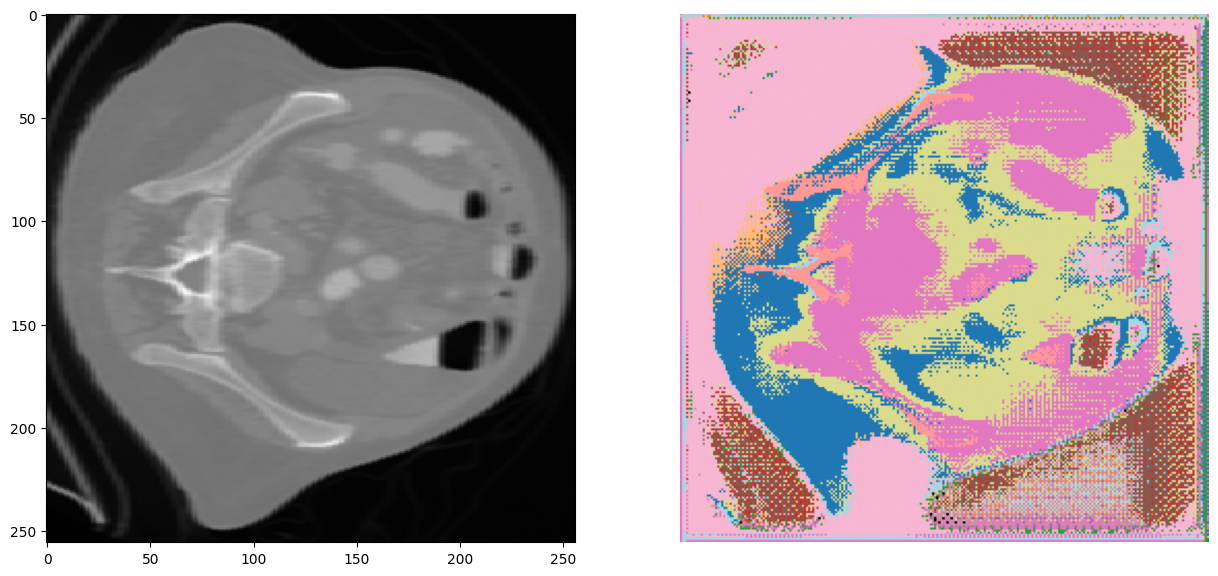

In [ ]:
from src.plotting import plt_pred
model_weights = torch.load(
    f'checkpoints/checkpoint_epoch{N_EPOCHS - 1}.pth',
    weights_only=True,
)
model = mk_model().eval()
model.load_state_dict(model_weights)
plt_pred(model, 100, x_train, y_train)
plt_pred(model, 6, x_valid, y_valid)
plt_pred(model, 6, x_test)

In [6]:
from tqdm import tqdm

from torch.utils.data import DataLoader


@torch.no_grad
def mk_submission(model: nn.Module, x_test: Tensor, batch_size: int=16):
    test_loader = DataLoader(x_test, batch_size=batch_size, shuffle=False)

    predictions = []

    for image in tqdm(test_loader) :
        image = image.to(device=device)

        y_pred_logits = model(image)

        pred = torch.argmax(y_pred_logits, dim=1)
        predictions.append(pred.cpu().numpy())

    predictions = np.array(predictions)
    print("n unique values:", len(np.unique(predictions)))
    df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T

    df.index = [f"Pixel {i}" for i in df.index]

    df.columns = [f"{col}.png" for col in df.columns]

    df.to_csv("submission.csv")

# mk_submission(model, x_test)